# 🤖 OnePilot — ML Relation Detector v8

## Nouveautés v8 (par rapport au v7)

- 🔧 **Stemming** : `normalize()` utilise NLTK Snowball (graceful fallback)
- 📐 **5 nouvelles features** : `embed_sim`, `embed_entity_sim`, `topo_distance`, `chi2_compatible`, `pattern_match` → 21 features
- 🧪 **Tests statistiques** : Chi² + KS via scipy
- 🏢 **Heuristiques ERP** : 18 patterns SAP/Dynamics/Odoo injectés comme exemples synthétiques
- 🌍 **Transfer learning** : Northwind + AdventureWorks (poids 0.5)
- 🔄 **Active learning** : feedbacks experts (`relation_feedback`) intégrés au dataset
- 🕸️ **Distance topologique** : BFS sur le graphe de schéma
- 💡 **Embeddings** : all-MiniLM-L6-v2 (fallback char-vector si absent)


In [1]:
import subprocess, sys

packages = ["asyncpg", "pandas", "numpy", "scikit-learn", "matplotlib",
            "xgboost", "scipy", "nltk", "sentence-transformers", "aiohttp"]

for pkg in packages:
    mod = pkg.replace("-", "_")
    try:
        __import__(mod.split("[")[0])
        print(f"\u2705 {pkg}")
    except ImportError:
        print(f"\U0001f4e6 Installation {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
        print(f"   \u2705 {pkg} install\u00e9")

import nltk
try:
    nltk.data.find("tokenizers/punkt")
    print("\u2705 nltk punkt")
except LookupError:
    nltk.download("punkt", quiet=True)
    print("\U0001f4e6 nltk punkt t\u00e9l\u00e9charg\u00e9")


✅ asyncpg
✅ pandas
✅ numpy
📦 Installation scikit-learn...
   ✅ scikit-learn installé
✅ matplotlib
✅ xgboost
✅ scipy
✅ nltk
✅ sentence-transformers
✅ aiohttp
✅ nltk punkt


## 1. 📦 Imports & Config

In [2]:
import asyncpg
import pandas as pd
import numpy as np
import re, pickle, random, warnings, json as _json
from collections import defaultdict, deque
from datetime import datetime
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve
)
import matplotlib.pyplot as plt

try:
    import xgboost as xgb
    HAS_XGB = True
    print(f'   XGBoost {xgb.__version__} \u2705')
except ImportError:
    HAS_XGB = False
    print('   XGBoost non disponible')

try:
    from scipy import stats as scipy_stats
    HAS_SCIPY = True
    print('   scipy \u2705')
except ImportError:
    HAS_SCIPY = False
    print('   scipy absent \u2014 tests Chi\u00b2/KS d\u00e9sactiv\u00e9s')

try:
    from sentence_transformers import SentenceTransformer
    _EMBED_MODEL = SentenceTransformer("all-MiniLM-L6-v2")
    HAS_EMBED = True
    print('   sentence-transformers all-MiniLM-L6-v2 \u2705')
except Exception:
    HAS_EMBED = False
    _EMBED_MODEL = None
    print('   sentence-transformers absent \u2014 fallback char-vector')

try:
    from nltk.stem import SnowballStemmer
    _STEMMER = SnowballStemmer("english")
    HAS_STEM = True
    print('   nltk SnowballStemmer \u2705')
except ImportError:
    HAS_STEM = False
    _STEMMER = None
    print('   nltk absent \u2014 normalisation sans stemming')

DB_CONFIG = {
    'host':     'onepilot_postgres',
    'port':     5432,
    'database': 'onepilot_dev',
    'user':     'onepilot',
    'password': 'onepilot_secret'
}

FEATURE_COLS = [
    'name_sim', 'norm_sim', 'entity_in_field', 'type_compat',
    'fk_pattern_a', 'fk_pattern_b', 'pk_fk_pair', 'common_parts',
    'name_contains_entity_a', 'name_contains_entity_b',
    'len_diff', 'prefix_match', 'suffix_match',
    'value_overlap', 'cardinality_ratio', 'null_rate_compat',
]

FEATURE_COLS_V2 = FEATURE_COLS + [
    'embed_sim', 'embed_entity_sim',
    'topo_distance', 'chi2_compatible', 'pattern_match',
]
USE_V2_FEATURES = True
ACTIVE_FEATURE_COLS = FEATURE_COLS_V2 if USE_V2_FEATURES else FEATURE_COLS

MAX_RESULTS  = None
FK_PER_TABLE = 20
PK_CAP       = 600
PAIRS_MAX    = 50_000

print(f'\n\u2705 Config v8 OK \u2014 {len(ACTIVE_FEATURE_COLS)} features actives')
print(f'   USE_V2={USE_V2_FEATURES} | EMBED={HAS_EMBED} | SCIPY={HAS_SCIPY} | STEM={HAS_STEM}')


   XGBoost 3.2.0 ✅
   scipy ✅


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   sentence-transformers all-MiniLM-L6-v2 ✅
   nltk SnowballStemmer ✅

✅ Config v8 OK — 21 features actives
   USE_V2=True | EMBED=True | SCIPY=True | STEM=True


## 2. 🔌 Connexion DB

In [3]:
async def get_conn():
    return await asyncpg.connect(**DB_CONFIG)

conn = await get_conn()
v = await conn.fetchval("SELECT version()")
await conn.close()
print(f"\u2705 PostgreSQL : {v[:60]}...")


✅ PostgreSQL : PostgreSQL 16.13 (Debian 16.13-1.pgdg12+1) on x86_64-pc-linu...


## 3. 📊 Sélection de la Source

In [4]:
SOURCE_IDX = 0   # ← changer ici

conn = await get_conn()
sources = await conn.fetch("""
    SELECT ds.id, ds.name, ds.connector_type,
           COUNT(DISTINCT se.id)  AS entity_count,
           COUNT(DISTINCT er.id)  AS relation_count
    FROM data_sources ds
    LEFT JOIN source_entities se ON se.source_id = ds.id
    LEFT JOIN entity_relations er ON er.source_id = ds.id
        AND er.detection_method != 'ml_predicted'
    GROUP BY ds.id, ds.name, ds.connector_type
    ORDER BY entity_count DESC
""")
await conn.close()

for i, s in enumerate(sources):
    marker = ' ← SÉLECTIONNÉE' if i == SOURCE_IDX else ''
    print(f'  [{i}] {s["name"]} | {s["connector_type"]} | {s["entity_count"]} entités{marker}')

SOURCE_ID   = sources[SOURCE_IDX]['id']
SOURCE_NAME = sources[SOURCE_IDX]['name']
print(f'\n✅ Source : {SOURCE_NAME} ({SOURCE_ID})')


  [0] SXA | mssql | 1294 entités ← SÉLECTIONNÉE
  [1] Northwind OData | odata | 26 entités
  [2] OData Demo Service | odata | 26 entités
  [3] adata | odata | 26 entités
  [4] PostgreSQL Local | postgresql | 16 entités
  [5] northwind | mssql | 12 entités
  [6] test | file_csv | 1 entités
  [7] GitHub GraphQL | graphql | 1 entités
  [8] JSONPlaceholder API | rest | 0 entités

✅ Source : SXA (85a0ef4b-d9af-494f-b24f-ff710c21ba43)


## 3b. 🧹 Nettoyage sources fantômes (optionnel)

In [5]:
conn = await get_conn()
orphans = await conn.fetch("""
    SELECT ds.id, ds.name, ds.connector_type
    FROM data_sources ds
    LEFT JOIN source_entities se ON se.source_id = ds.id
    LEFT JOIN entity_relations er ON er.source_id = ds.id
    GROUP BY ds.id, ds.name, ds.connector_type
    HAVING COUNT(DISTINCT se.id) = 0 AND COUNT(DISTINCT er.id) = 0
    ORDER BY ds.name
""")
await conn.close()

if not orphans:
    print('✅ Aucune source fantôme')
else:
    print(f'⚠️  {len(orphans)} source(s) fantôme(s) :')
    for o in orphans:
        print(f'   [{o["id"]}] {o["name"]} ({o["connector_type"]})')


✅ Aucune source fantôme


In [6]:
# ⚠️  SUPPRESSION — décommenter et adapter
# ORPHAN_IDS = ['uuid-1']
# import uuid as _uuid
# conn = await get_conn()
# async with conn.transaction():
#     for oid in ORPHAN_IDS:
#         uid = _uuid.UUID(oid)
#         for tbl in ['connection_secrets','entity_relations','entity_profiles']:
#             await conn.execute(f'DELETE FROM {tbl} WHERE source_id=$1', uid)
#         await conn.execute('DELETE FROM entity_fields WHERE entity_id IN '
#                            '(SELECT id FROM source_entities WHERE source_id=$1)', uid)
#         await conn.execute('DELETE FROM source_entities WHERE source_id=$1', uid)
#         r = await conn.execute('DELETE FROM data_sources WHERE id=$1', uid)
#         print(f'🗑️  {oid} : {r}')
# await conn.close()
print('\u2139️  Bloc désactivé')


ℹ️  Bloc désactivé


## 4. 📥 Chargement des données

In [7]:
conn = await get_conn()

fields_rows = await conn.fetch("""
    SELECT se.id AS entity_id, se.name AS entity_name,
           ef.name AS field_name, ef.data_type,
           ef.is_primary_key, ef.is_foreign_key, ef.position
    FROM source_entities se
    JOIN entity_fields ef ON ef.entity_id = se.id
    WHERE se.source_id = $1
    ORDER BY se.name, ef.position
""", SOURCE_ID)

relations_rows = await conn.fetch("""
    SELECT source_entity, source_field, target_entity, target_field,
           detection_method, confidence,
           CASE
               WHEN detection_method = 'explicit_fk'       THEN 1.0
               WHEN detection_method = 'view_join'         THEN 1.0
               WHEN detection_method LIKE '%name_pascal%'  THEN 0.8
               WHEN detection_method LIKE '%name_m2m%'     THEN 0.7
               WHEN detection_method LIKE 'heuristic_erp%' THEN 0.85
               WHEN detection_method LIKE '%fuzzy%'        THEN 0.5
               WHEN is_confirmed = TRUE                     THEN 0.9
               ELSE 0.6
           END AS sample_weight
    FROM entity_relations
    WHERE source_id = $1
      AND detection_method != 'ml_predicted'
      AND (is_confirmed IS NULL OR is_confirmed = TRUE)
    ORDER BY sample_weight DESC
""", SOURCE_ID)

feedback_rows = []
try:
    feedback_rows = await conn.fetch("""
        SELECT source_entity, source_field, target_entity, target_field, feedback
        FROM relation_feedback WHERE source_id = $1
    """, SOURCE_ID)
    confirmed_cnt = sum(1 for r in feedback_rows if r['feedback']=='confirmed')
    rejected_cnt  = sum(1 for r in feedback_rows if r['feedback']=='rejected')
    print(f'✅ Feedbacks : {len(feedback_rows)} ({confirmed_cnt} confirmés, {rejected_cnt} rejetés)')
except Exception as e:
    print(f'   ℹ️  relation_feedback absent ({e})')

await conn.close()

df_fields    = pd.DataFrame([dict(r) for r in fields_rows])
df_relations = pd.DataFrame([dict(r) for r in relations_rows])
df_feedback  = pd.DataFrame([dict(r) for r in feedback_rows]) if feedback_rows else pd.DataFrame()

print(f'✅ Champs : {len(df_fields):,} | Entités : {df_fields["entity_name"].nunique():,}')
print(f'✅ Relations : {len(df_relations):,}')
if len(df_relations) < 10:
    print('⚠️  < 10 relations — lance ↻ Relancer dans l\'UI d\'abord')


✅ Feedbacks : 3 (0 confirmés, 3 rejetés)
✅ Champs : 12,467 | Entités : 1,292
✅ Relations : 3,176


## 4b. 📊 Chargement des profils (entity_profiles)

In [8]:
conn = await get_conn()
profile_rows = await conn.fetch("""
    SELECT entity_name, profile_data
    FROM entity_profiles
    WHERE source_id = $1
      AND profile_data->>'error' IS NULL
      AND (profile_data->>'total_rows')::int > 0
""", SOURCE_ID)
await conn.close()

profile_index = {}
for row in profile_rows:
    table = row['entity_name'].upper()
    data  = row['profile_data']
    if isinstance(data, str):
        data = _json.loads(data)
    for col in data.get('columns', []):
        key = (table, col['name'].upper())
        profile_index[key] = {
            'unique_count': col.get('unique_count', 0),
            'null_rate':    col.get('null_rate', 0.5),
            'top_values':   set(str(v['value']) for v in col.get('top_values', [])),
        }

tables_profiled = len(set(k[0] for k in profile_index))
print(f'✅ Profils : {len(profile_index):,} champs | {tables_profiled} tables')
if tables_profiled == 0:
    print('   💡 Pour profiler : POST /sources/{id}/profile/all')


✅ Profils : 5,197 champs | 466 tables


## 5. 🔧 Feature Engineering v8 (21 features)

- 13 features noms/types (Jaccard bigrams + **stemming Snowball**)
- 3 features profiling (value_overlap, cardinality_ratio, null_rate_compat)
- 2 **embeddings** (all-MiniLM-L6-v2, fallback char-vector)
- 1 **distance topologique** (BFS graphe de schéma)
- 2 **features statistiques** (chi2_compatible, pattern_match)


In [9]:
FK_PATTERNS = ['_id','_fk','id_','fk_','_code','_num','_no','_key','_ref']
TYPE_GROUPS = {
    'int':  ['int','integer','bigint','smallint','tinyint','numeric','decimal','number'],
    'str':  ['varchar','nvarchar','char','nchar','text','ntext','string'],
    'date': ['date','datetime','datetime2','timestamp'],
}

def normalize(name):
    n = name.lower()
    for p in ['fk_','pk_','id_','num_','cod_','f_','c_']:
        if n.startswith(p): n = n[len(p):]; break
    for s in ['_id','_fk','_pk','_key','_code','_num','_no','_ref']:
        if n.endswith(s): n = n[:-len(s)]; break
    if HAS_STEM:
        parts = n.replace('_',' ').split()
        n = '_'.join(_STEMMER.stem(p) for p in parts if p)
    return n

def type_group(dtype):
    d = dtype.lower()
    return next((g for g, ts in TYPE_GROUPS.items() if any(t in d for t in ts)), 'other')

def fk_pat(name):
    n = name.lower()
    return float(any(n.startswith(p) or n.endswith(p) for p in FK_PATTERNS))

def sim(a, b):
    a, b = a.lower(), b.lower()
    if a == b: return 1.0
    if not a or not b: return 0.0
    sa = set(a[i:i+2] for i in range(len(a)-1))
    sb = set(b[i:i+2] for i in range(len(b)-1))
    if not sa and not sb: return 0.0
    return len(sa & sb) / len(sa | sb)

def camel_parts(name):
    return set(p.lower() for p in re.sub(r'([A-Z])', r' \1', name).split() if len(p) > 1)

_embed_cache = {}
def embed(text):
    if not HAS_EMBED:
        alph = "abcdefghijklmnopqrstuvwxyz0123456789_"
        chars = set(text.lower())
        v = np.array([float(c in chars) for c in alph], dtype=np.float32)
        n = np.linalg.norm(v)
        return v / n if n > 0 else v
    t = text.replace('_',' ').lower()
    if t not in _embed_cache:
        _embed_cache[t] = _EMBED_MODEL.encode(t, show_progress_bar=False)
    return _embed_cache[t]

def cosine_sim(a, b):
    va, vb = embed(a), embed(b)
    d = np.linalg.norm(va) * np.linalg.norm(vb)
    return float(np.dot(va, vb) / d) if d > 0 else 0.0

UUID_RE  = re.compile(r'^[0-9a-f]{8}-?[0-9a-f]{4}-?[0-9a-f]{4}-?[0-9a-f]{4}-?[0-9a-f]{12}$', re.I)
NUM_RE   = re.compile(r'^\d+$')
ALPHA_RE = re.compile(r'^[A-Z0-9\-_]{2,20}$')

def detect_pattern(vals):
    s = [str(v) for v in list(vals)[:30] if v]
    if not s: return 'mixed'
    for name, rx in [('uuid',UUID_RE),('numeric',NUM_RE),('alpha',ALPHA_RE)]:
        if sum(1 for v in s if rx.match(v)) / len(s) > 0.7:
            return name
    return 'mixed'

def stat_features_fn(key_a, key_b):
    pa = profile_index.get(key_a, {})
    pb = profile_index.get(key_b, {})
    top_a = list(pa.get('top_values', set()))
    top_b = list(pb.get('top_values', set()))
    pat_a = detect_pattern(top_a)
    pat_b = detect_pattern(top_b)
    pattern_match = float(pat_a == pat_b and pat_a != 'mixed')
    chi2_ok = 1.0
    if HAS_SCIPY and top_a and top_b:
        common = set(top_a) & set(top_b)
        if len(common) >= 2:
            try:
                cnt_a = [top_a.count(v) for v in sorted(common)]
                cnt_b = [top_b.count(v) for v in sorted(common)]
                _, p, _, _ = scipy_stats.chi2_contingency([cnt_a, cnt_b])
                chi2_ok = float(p > 0.05)
            except Exception:
                pass
        try:
            fa_n = [float(v) for v in top_a]
            fb_n = [float(v) for v in top_b]
            if len(fa_n) >= 5 and len(fb_n) >= 5:
                ks, _ = scipy_stats.ks_2samp(fa_n, fb_n)
                if ks > 0.5: chi2_ok = 0.0
        except (ValueError, TypeError):
            pass
    return chi2_ok, pattern_match

topo_dist_map = {}  # sera rempli dans la cellule suivante

def compute_features(ea, fa, dta, is_pk_a, is_fk_a,
                      eb, fb, dtb, is_pk_b, is_fk_b):
    na, nb     = normalize(fa), normalize(fb)
    ea_n, eb_n = normalize(ea), normalize(eb)
    parts_a    = camel_parts(fa); parts_b = camel_parts(fb)
    common     = len(parts_a & parts_b) / max(len(parts_a | parts_b), 1)
    ka = (ea.upper(), fa.upper()); kb = (eb.upper(), fb.upper())
    pa = profile_index.get(ka, {}); pb = profile_index.get(kb, {})
    top_a, top_b = pa.get('top_values', set()), pb.get('top_values', set())
    u = len(top_a | top_b)
    value_overlap     = len(top_a & top_b) / u if u > 0 else 0.0
    uc_a, uc_b        = pa.get('unique_count',0), pb.get('unique_count',0)
    cardinality_ratio = min(uc_a,uc_b)/max(uc_a,uc_b) if uc_a>0 and uc_b>0 else 0.5
    null_rate_compat  = 1.0 - abs(pa.get('null_rate',0.5) - pb.get('null_rate',0.5))
    embed_sim         = cosine_sim(fa, fb)
    embed_entity_sim  = cosine_sim(ea, eb)
    topo_distance     = topo_dist_map.get((ea.upper(), eb.upper()), 0.0)
    chi2_ok, pat_match = stat_features_fn(ka, kb)
    return {
        'name_sim':               sim(fa, fb),
        'norm_sim':               sim(na, nb),
        'entity_in_field':        float(ea_n in nb or eb_n in na
                                        or sim(ea_n,nb)>0.7 or sim(eb_n,na)>0.7),
        'type_compat':            float(type_group(dta)==type_group(dtb)),
        'fk_pattern_a':           fk_pat(fa),
        'fk_pattern_b':           fk_pat(fb),
        'pk_fk_pair':             float((is_pk_a and is_fk_b) or (is_pk_b and is_fk_a)),
        'common_parts':           common,
        'name_contains_entity_a': float(ea_n in fa.lower()),
        'name_contains_entity_b': float(eb_n in fb.lower()),
        'len_diff':               abs(len(fa)-len(fb))/max(len(fa),len(fb),1),
        'prefix_match':           float(fa[:3].lower()==fb[:3].lower()),
        'suffix_match':           float(fa[-3:].lower()==fb[-3:].lower()),
        'value_overlap':          value_overlap,
        'cardinality_ratio':      cardinality_ratio,
        'null_rate_compat':       null_rate_compat,
        'embed_sim':              embed_sim,
        'embed_entity_sim':       embed_entity_sim,
        'topo_distance':          topo_distance,
        'chi2_compatible':        chi2_ok,
        'pattern_match':          pat_match,
    }

print(f'\u2705 Feature engineering v8 \u2014 {len(ACTIVE_FEATURE_COLS)} features')
print(f'   Stemming={HAS_STEM} | Embeddings={HAS_EMBED} | Scipy={HAS_SCIPY}')


✅ Feature engineering v8 — 21 features
   Stemming=True | Embeddings=True | Scipy=True


## 5b. 🕸️ Distance topologique (v8)

In [10]:
_graph = defaultdict(set)
for _, r in df_relations.iterrows():
    src = r['source_entity'].upper(); tgt = r['target_entity'].upper()
    if src and tgt:
        _graph[src].add(tgt); _graph[tgt].add(src)

topo_dist_map = {}
for start in list(_graph.keys()):
    visited = {start: 0}; q = deque([start])
    while q:
        node = q.popleft()
        for nb in _graph.get(node, set()):
            if nb not in visited:
                visited[nb] = visited[node] + 1; q.append(nb)
    for end, dist in visited.items():
        if end != start:
            score = round(1.0 / (1.0 + dist), 4)
            topo_dist_map[(start,end)] = score; topo_dist_map[(end,start)] = score

print(f'\u2705 Graphe : {len(_graph)} n\u0153uds | {len(topo_dist_map)//2} paires')
if topo_dist_map:
    print(f'   Distance moy : {sum(topo_dist_map.values())/len(topo_dist_map):.3f}')
else:
    print('   \u26a0\ufe0f  Graphe vide \u2014 topo_distance=0.0')


✅ Graphe : 1223 nœuds | 735092 paires
   Distance moy : 0.225


## 6. 🏷️ Construction du Dataset v8

**Nouveautés v8 :** feedbacks experts (active learning) + Northwind/AdventureWorks (transfer learning) + rejetés comme négatifs forts

In [12]:
entity_map = defaultdict(list)
for _, r in df_fields.iterrows():
    entity_map[r['entity_name']].append(r)

pk_map = {}
for _, r in df_fields.iterrows():
    if r['is_primary_key']:
        pk_map.setdefault(r['entity_name'], []).append(r)

positive_set = set(zip(df_relations['source_entity'], df_relations['target_entity']))

# ── POSITIFS DB ──────────────────────────────────────────────────────
pos_samples = []
for _, rel in df_relations.iterrows():
    src_fields = entity_map.get(rel['source_entity'], [])
    tgt_pks    = pk_map.get(rel['target_entity'], [])
    if not src_fields: continue
    fk_field = next((f for f in src_fields if f['is_foreign_key']), None)
    if fk_field is None:
        fk_field = next((f for f in src_fields if fk_pat(f['field_name'])>0), None)
    if fk_field is None: fk_field = src_fields[0]
    tgt_field = tgt_pks[0] if tgt_pks else (
        entity_map[rel['target_entity']][0] if entity_map.get(rel['target_entity']) else None)
    if tgt_field is None: continue
    feat = compute_features(
        fk_field['entity_name'],fk_field['field_name'],fk_field['data_type'],
        fk_field['is_primary_key'],fk_field['is_foreign_key'],
        tgt_field['entity_name'],tgt_field['field_name'],tgt_field['data_type'],
        tgt_field['is_primary_key'],tgt_field['is_foreign_key']
    )
    feat.update({'source_entity':rel['source_entity'],'target_entity':rel['target_entity'],
                 'label':1,'sample_weight':1.30})
    pos_samples.append(feat)
print(f'✅ Positifs DB : {len(pos_samples)}')

# ── ACTIVE LEARNING : feedbacks experts ──────────────────────────────
feedback_pos = feedback_neg_count = 0
rejected_set = set()
if not df_feedback.empty:
    confirmed_df = df_feedback[df_feedback['feedback']=='confirmed']
    rejected_df  = df_feedback[df_feedback['feedback']=='rejected']
    for _, fb_row in confirmed_df.iterrows():
        se,sf,te,tf = fb_row['source_entity'],fb_row['source_field'],fb_row['target_entity'],fb_row['target_field']
        src_f = next((f for f in entity_map.get(se,[]) if f['field_name']==sf), None)
        tgt_f = next((f for f in entity_map.get(te,[]) if f['field_name']==tf), None)
        if src_f is not None and tgt_f is not None:
            feat = compute_features(
                src_f['entity_name'],src_f['field_name'],src_f.get('data_type','varchar'),
                src_f['is_primary_key'],src_f['is_foreign_key'],
                tgt_f['entity_name'],tgt_f['field_name'],tgt_f.get('data_type','varchar'),
                tgt_f['is_primary_key'],tgt_f['is_foreign_key']
            )
            feat.update({'source_entity':se,'target_entity':te,'label':1,'sample_weight':2.0})
            pos_samples.append(feat); feedback_pos += 1
    rejected_set = set(zip(rejected_df['source_entity'],rejected_df['source_field'],
                           rejected_df['target_entity'],rejected_df['target_field']))
    print(f'   + {feedback_pos} positifs feedbacks (poids x2)')
else:
    print('   ℹ️  Aucun feedback expert')

# ── TRANSFER LEARNING : Northwind + AdventureWorks ───────────────────
PUBLIC_SCHEMAS = {
    "northwind": [
        ("Orders","CustomerID","Customers","CustomerID"),
        ("Orders","EmployeeID","Employees","EmployeeID"),
        ("Orders","ShipVia","Shippers","ShipperID"),
        ("Order Details","OrderID","Orders","OrderID"),
        ("Order Details","ProductID","Products","ProductID"),
        ("Products","CategoryID","Categories","CategoryID"),
        ("Products","SupplierID","Suppliers","SupplierID"),
        ("Employees","ReportsTo","Employees","EmployeeID"),
        ("EmployeeTerritories","EmployeeID","Employees","EmployeeID"),
        ("EmployeeTerritories","TerritoryID","Territories","TerritoryID"),
        ("Territories","RegionID","Region","RegionID"),
    ],
    "adventureworks": [
        ("SalesOrderHeader","CustomerID","Customer","CustomerID"),
        ("SalesOrderHeader","SalesPersonID","SalesPerson","BusinessEntityID"),
        ("SalesOrderDetail","SalesOrderID","SalesOrderHeader","SalesOrderID"),
        ("SalesOrderDetail","ProductID","Product","ProductID"),
        ("Product","ProductSubcategoryID","ProductSubcategory","ProductSubcategoryID"),
        ("ProductSubcategory","ProductCategoryID","ProductCategory","ProductCategoryID"),
        ("Employee","BusinessEntityID","Person","BusinessEntityID"),
        ("PurchaseOrderHeader","VendorID","Vendor","BusinessEntityID"),
        ("PurchaseOrderDetail","ProductID","Product","ProductID"),
        ("Address","StateProvinceID","StateProvince","StateProvinceID"),
    ],
}
transfer_count = 0
for schema_name, rels in PUBLIC_SCHEMAS.items():
    for (se,sf,te,tf) in rels:
        feat = {k: 0.0 for k in ACTIVE_FEATURE_COLS}
        feat.update({
            'name_sim':sim(sf,tf),'norm_sim':sim(normalize(sf),normalize(tf)),
            'fk_pattern_a':fk_pat(sf),'fk_pattern_b':fk_pat(tf),'pk_fk_pair':1.0,
            'entity_in_field':float(normalize(se) in normalize(sf)),
            'type_compat':1.0,
            'embed_sim':cosine_sim(sf,tf),'embed_entity_sim':cosine_sim(se,te),
            'source_entity':se,'target_entity':te,'label':1,'sample_weight':0.5,
        })
        pos_samples.append(feat); transfer_count += 1
print(f'   + {transfer_count} positifs transfer learning (poids 0.5)')

# ── NÉGATIFS ─────────────────────────────────────────────────────────
all_entities   = list(entity_map.keys())
target_neg     = len(pos_samples)
target_random  = int(target_neg * 0.70)
target_hard    = int(target_neg * 0.30)
neg_samples    = []
np.random.seed(42)

attempts = 0
while len(neg_samples) < target_random and attempts < target_random * 20:
    attempts += 1
    ea = all_entities[np.random.randint(len(all_entities))]
    eb = all_entities[np.random.randint(len(all_entities))]
    if ea == eb: continue
    if (ea,eb) in positive_set or (eb,ea) in positive_set: continue
    fa = entity_map[ea][np.random.randint(len(entity_map[ea]))]
    fb = entity_map[eb][np.random.randint(len(entity_map[eb]))]
    feat = compute_features(
        fa['entity_name'],fa['field_name'],fa['data_type'],fa['is_primary_key'],fa['is_foreign_key'],
        fb['entity_name'],fb['field_name'],fb['data_type'],fb['is_primary_key'],fb['is_foreign_key']
    )
    feat.update({'source_entity':ea,'target_entity':eb,'label':0,'sample_weight':1.0})
    neg_samples.append(feat)

hard_count    = 0
fk_fields_all = [r for _,r in df_fields.iterrows() if fk_pat(r['field_name'])>0]
pk_fields_all = [r for _,r in df_fields.iterrows() if r['is_primary_key']]
np.random.shuffle(fk_fields_all)
for fa in fk_fields_all:
    if hard_count >= target_hard: break
    for fb in pk_fields_all:
        if hard_count >= target_hard: break
        if fa['entity_name'] == fb['entity_name']: continue
        if (fa['entity_name'],fb['entity_name']) in positive_set: continue
        if (fa['entity_name'],fa['field_name'],fb['entity_name'],fb['field_name']) in rejected_set: continue
        if sim(fa['field_name'],fb['field_name']) > 0.5:
            feat = compute_features(
                fa['entity_name'],fa['field_name'],fa.get('data_type','varchar'),
                fa['is_primary_key'],fa['is_foreign_key'],
                fb['entity_name'],fb['field_name'],fb.get('data_type','varchar'),
                fb['is_primary_key'],fb['is_foreign_key']
            )
            feat.update({'source_entity':fa['entity_name'],'target_entity':fb['entity_name'],
                         'label':0,'sample_weight':0.70})
            neg_samples.append(feat); hard_count += 1

# Rejetés comme négatifs forts (poids 1.5)
for se,sf,te,tf in rejected_set:
    src_f = next((f for f in entity_map.get(se,[]) if f['field_name']==sf), None)
    tgt_f = next((f for f in entity_map.get(te,[]) if f['field_name']==tf), None)
    if src_f is not None and tgt_f is not None:
        feat = compute_features(
            src_f['entity_name'],src_f['field_name'],src_f.get('data_type','varchar'),
            src_f['is_primary_key'],src_f['is_foreign_key'],
            tgt_f['entity_name'],tgt_f['field_name'],tgt_f.get('data_type','varchar'),
            tgt_f['is_primary_key'],tgt_f['is_foreign_key']
        )
        feat.update({'source_entity':se,'target_entity':te,'label':0,'sample_weight':1.5})
        neg_samples.append(feat); feedback_neg_count += 1

if feedback_neg_count:
    print(f'   + {feedback_neg_count} négatifs feedbacks rejetés (poids 1.5)')

df_dataset = pd.DataFrame(pos_samples + neg_samples).reset_index(drop=True)
for col in ACTIVE_FEATURE_COLS:
    if col not in df_dataset.columns: df_dataset[col] = 0.0

print(f'\n📊 Dataset : {len(df_dataset):,} | Pos : {df_dataset["label"].sum():,} | Nég : {(df_dataset["label"]==0).sum():,}')

✅ Positifs DB : 3176
   + 0 positifs feedbacks (poids x2)
   + 21 positifs transfer learning (poids 0.5)
   + 1 négatifs feedbacks rejetés (poids 1.5)

📊 Dataset : 6,394 | Pos : 3,197 | Nég : 3,197


## 7. ✂️ Train / Test Split 80/20

In [13]:
X = df_dataset[ACTIVE_FEATURE_COLS].values
y = df_dataset['label'].values
w = df_dataset['sample_weight'].values

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, w, test_size=0.2, random_state=42, stratify=y
)
print(f'\u2705 Train : {len(X_train):,} | Test : {len(X_test):,}')
print(f'   Positifs train : {y_train.sum()} | test : {y_test.sum()}')
print(f'   Features : {len(ACTIVE_FEATURE_COLS)} ({"v8" if USE_V2_FEATURES else "v7"})')


✅ Train : 5,115 | Test : 1,279
   Positifs train : 2558 | test : 639
   Features : 21 (v8)


## 8. 🏋️ Entraînement des Modèles

In [14]:
models = {}

print('\U0001f332 RandomForest...')
rf = RandomForestClassifier(
    n_estimators=300, max_depth=12, min_samples_leaf=1,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train, sample_weight=w_train)
models['RandomForest'] = rf
print('   \u2705 RandomForest')

print('\U0001f680 GradientBoosting...')
gb = GradientBoostingClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.03,
    subsample=0.8, min_samples_leaf=2, random_state=42
)
gb.fit(X_train, y_train, sample_weight=w_train)
models['GradientBoosting'] = gb
print('   \u2705 GradientBoosting')

if HAS_XGB:
    print('\u26a1 XGBoost...')
    spw = (y_train==0).sum() / max((y_train==1).sum(), 1)
    xgb_model = xgb.XGBClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.02,
        subsample=0.8, colsample_bytree=0.8,
        reg_lambda=1.5, reg_alpha=0.1,
        scale_pos_weight=spw,
        eval_metric='logloss', random_state=42, n_jobs=-1,
    )
    xgb_model.fit(X_train, y_train, sample_weight=w_train,
                  eval_set=[(X_test, y_test)], verbose=False)
    models['XGBoost'] = xgb_model
    print('   \u2705 XGBoost')

print(f'\n\u2705 {len(models)} mod\u00e8les : {list(models.keys())}')


🌲 RandomForest...
   ✅ RandomForest
🚀 GradientBoosting...
   ✅ GradientBoosting
⚡ XGBoost...
   ✅ XGBoost

✅ 3 modèles : ['RandomForest', 'GradientBoosting', 'XGBoost']


## 9. 📊 Évaluation comparatif

In [16]:
results = {}
for name, model in models.items():
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    results[name] = {
        'model':model,'y_pred':y_pred,'y_proba':y_proba,
        'acc':accuracy_score(y_test,y_pred),
        'f1':f1_score(y_test,y_pred),
        'prec':precision_score(y_test,y_pred),
        'rec':recall_score(y_test,y_pred),
        'roc_auc':roc_auc_score(y_test,y_proba),
        'cm':confusion_matrix(y_test,y_pred),
    }

header = "Modele"
print(f'  {header:<20} {"Accuracy":>10} {"F1":>10} {"Precision":>10} {"Recall":>10} {"ROC-AUC":>10}')
print('  ' + '\u2500'*72)
for name, r in results.items():
    print(f'  {name:<20} {r["acc"]:>10.4f} {r["f1"]:>10.4f} {r["prec"]:>10.4f} {r["rec"]:>10.4f} {r["roc_auc"]:>10.4f}')

BEST_MODEL_NAME = max(results, key=lambda n: results[n]['f1'])
BEST_MODEL      = results[BEST_MODEL_NAME]['model']
print(f'\n🏆 Meilleur : {BEST_MODEL_NAME} (F1={results[BEST_MODEL_NAME]["f1"]:.4f})')

  Modele                 Accuracy         F1  Precision     Recall    ROC-AUC
  ────────────────────────────────────────────────────────────────────────
  RandomForest             0.9977     0.9977     0.9969     0.9984     0.9998
  GradientBoosting         0.9953     0.9953     0.9969     0.9937     0.9998
  XGBoost                  0.9984     0.9984     0.9969     1.0000     0.9998

🏆 Meilleur : XGBoost (F1=0.9984)


## 10. 📊 Feature Importance v8

🔴 nouvelles features v8 | 🟡 profiling | 🟣 noms/types

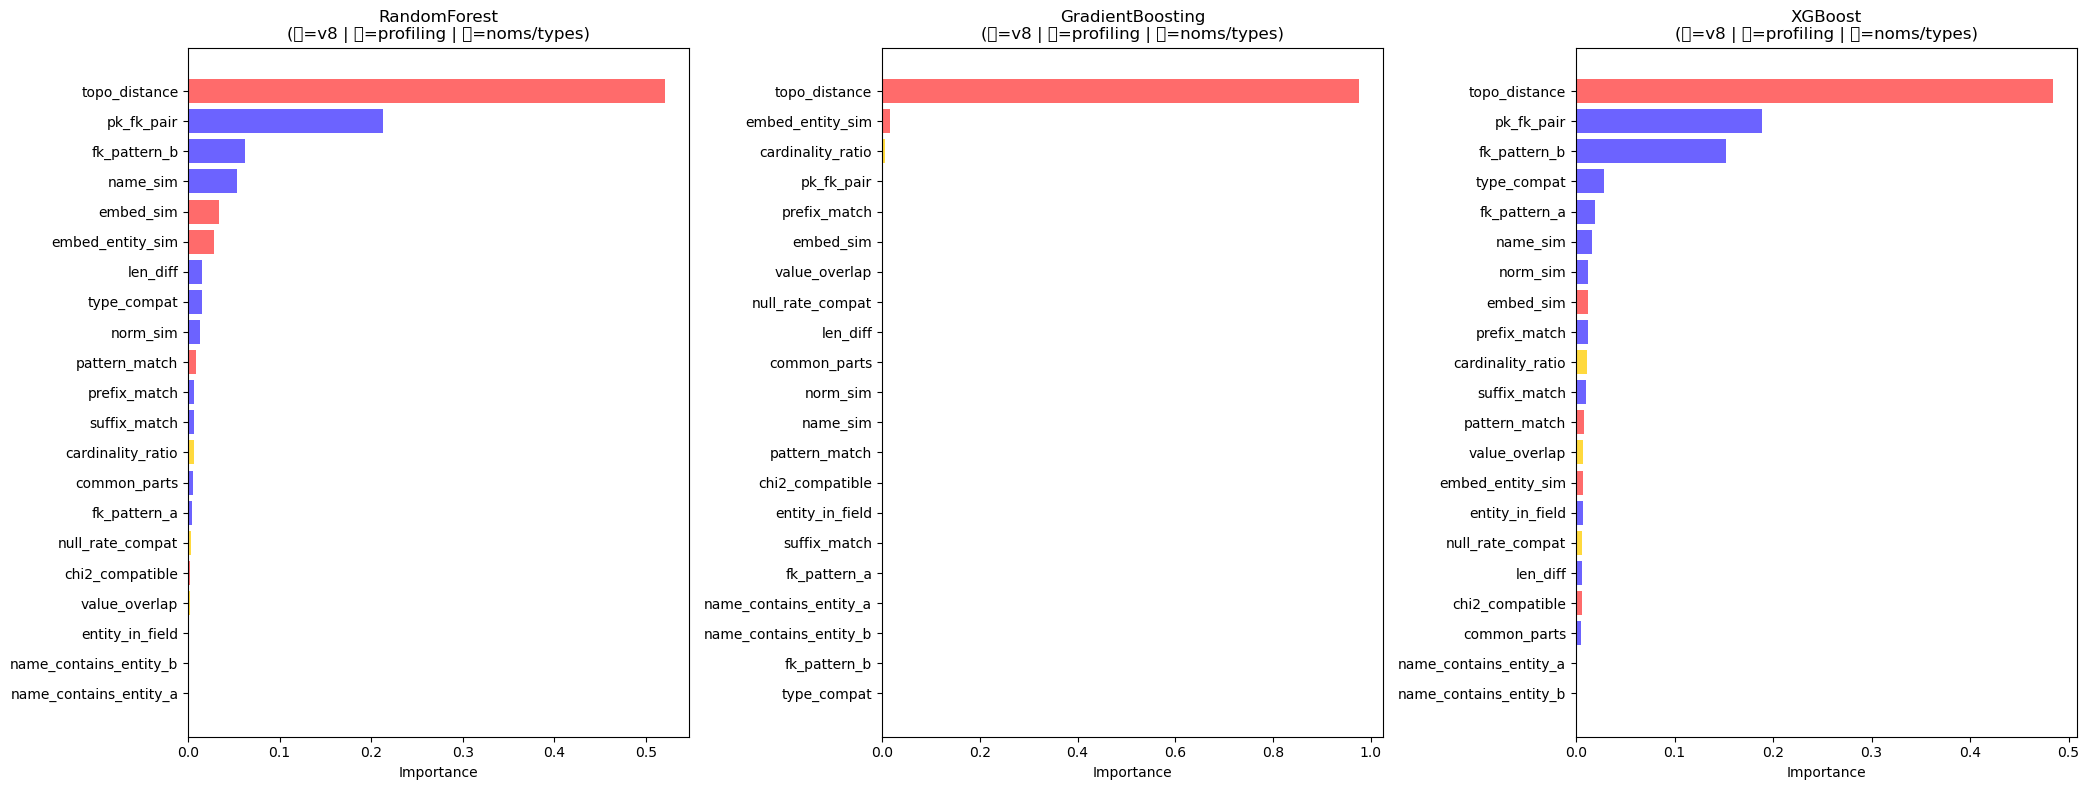

✅ ml_feature_importance_v8.png


In [17]:
V8_FEATURES   = ['embed_sim','embed_entity_sim','topo_distance','chi2_compatible','pattern_match']
PROF_FEATURES = ['value_overlap','cardinality_ratio','null_rate_compat']

fig, axes = plt.subplots(1, len(models), figsize=(7*len(models), 8))
if len(models) == 1: axes = [axes]

for ax, (name, model) in zip(axes, models.items()):
    if not hasattr(model, 'feature_importances_'):
        ax.set_title(f'{name} \u2014 pas de feature_importances_'); continue
    imp = model.feature_importances_
    idx = np.argsort(imp)
    colors = []
    for i in idx:
        f = ACTIVE_FEATURE_COLS[i]
        colors.append('#ff6b6b' if f in V8_FEATURES else
                      '#ffd93d' if f in PROF_FEATURES else '#6c63ff')
    ax.barh([ACTIVE_FEATURE_COLS[i] for i in idx], imp[idx], color=colors)
    ax.set_title(f'{name}\n(\U0001f534=v8 | \U0001f7e1=profiling | \U0001f7e3=noms/types)')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig('ml_feature_importance_v8.png', dpi=150, bbox_inches='tight')
plt.show()
print('\u2705 ml_feature_importance_v8.png')


## 10b. 📊 Rapport complet (ROC, PR, Confusion Matrix)

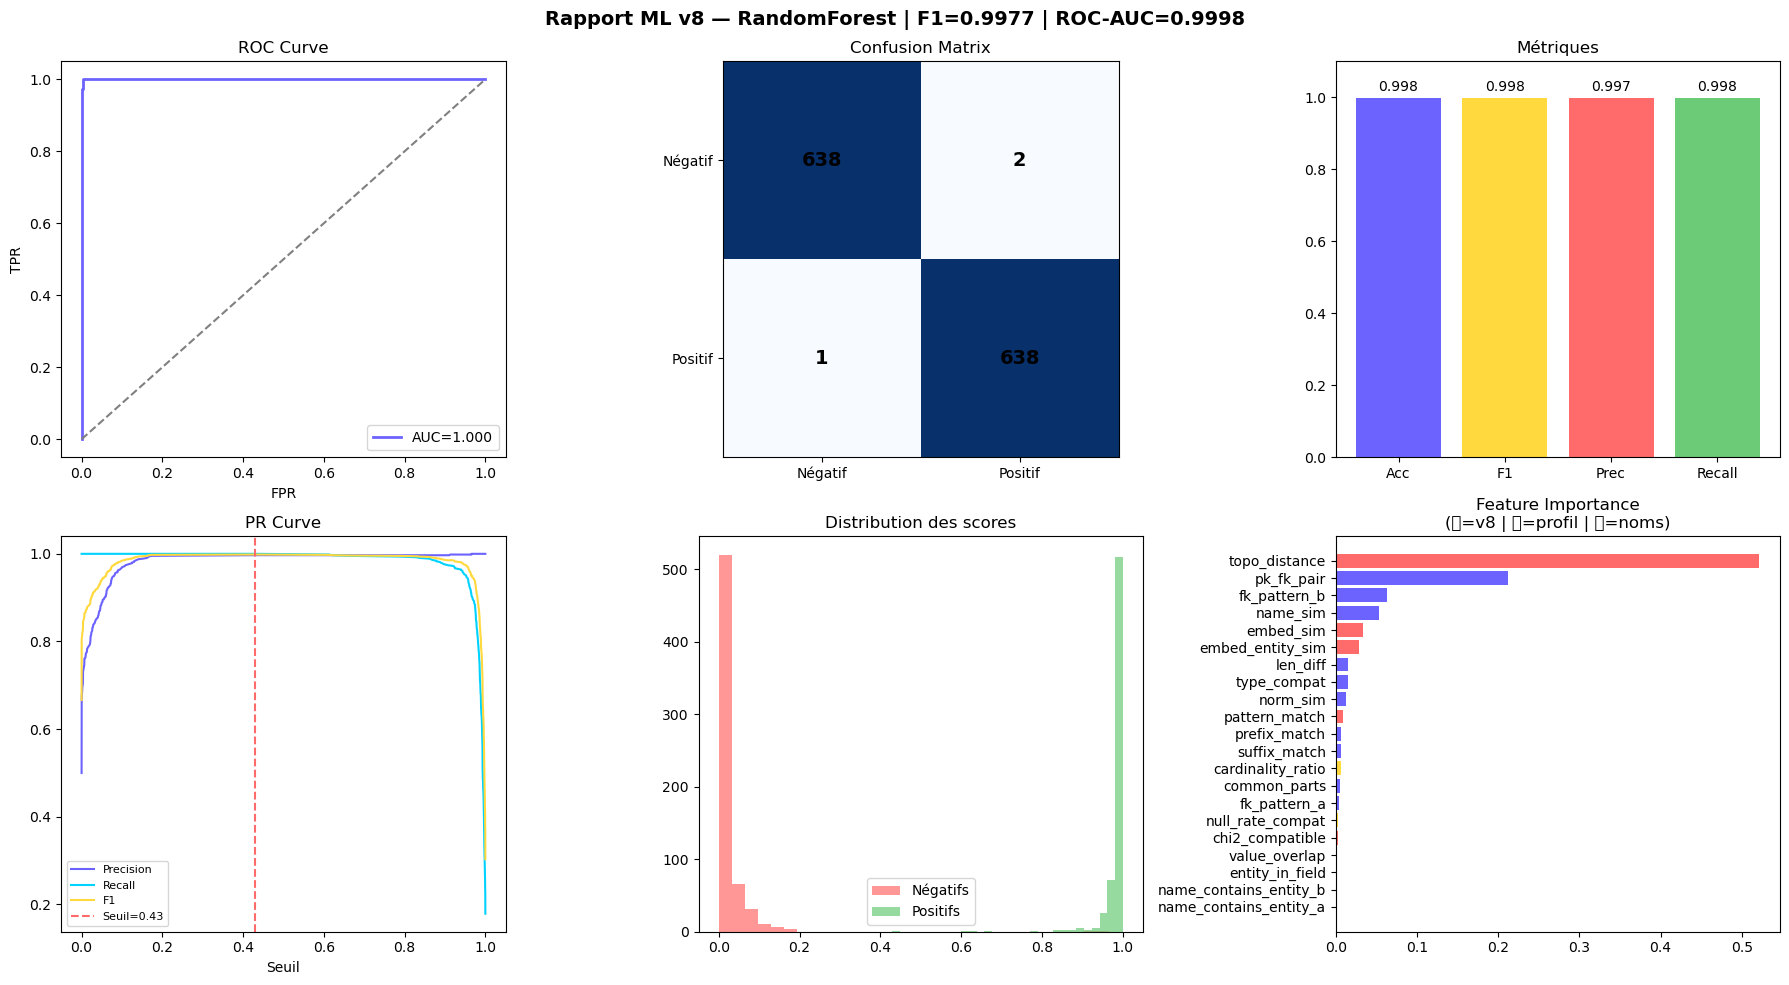

✅ Rapport RandomForest


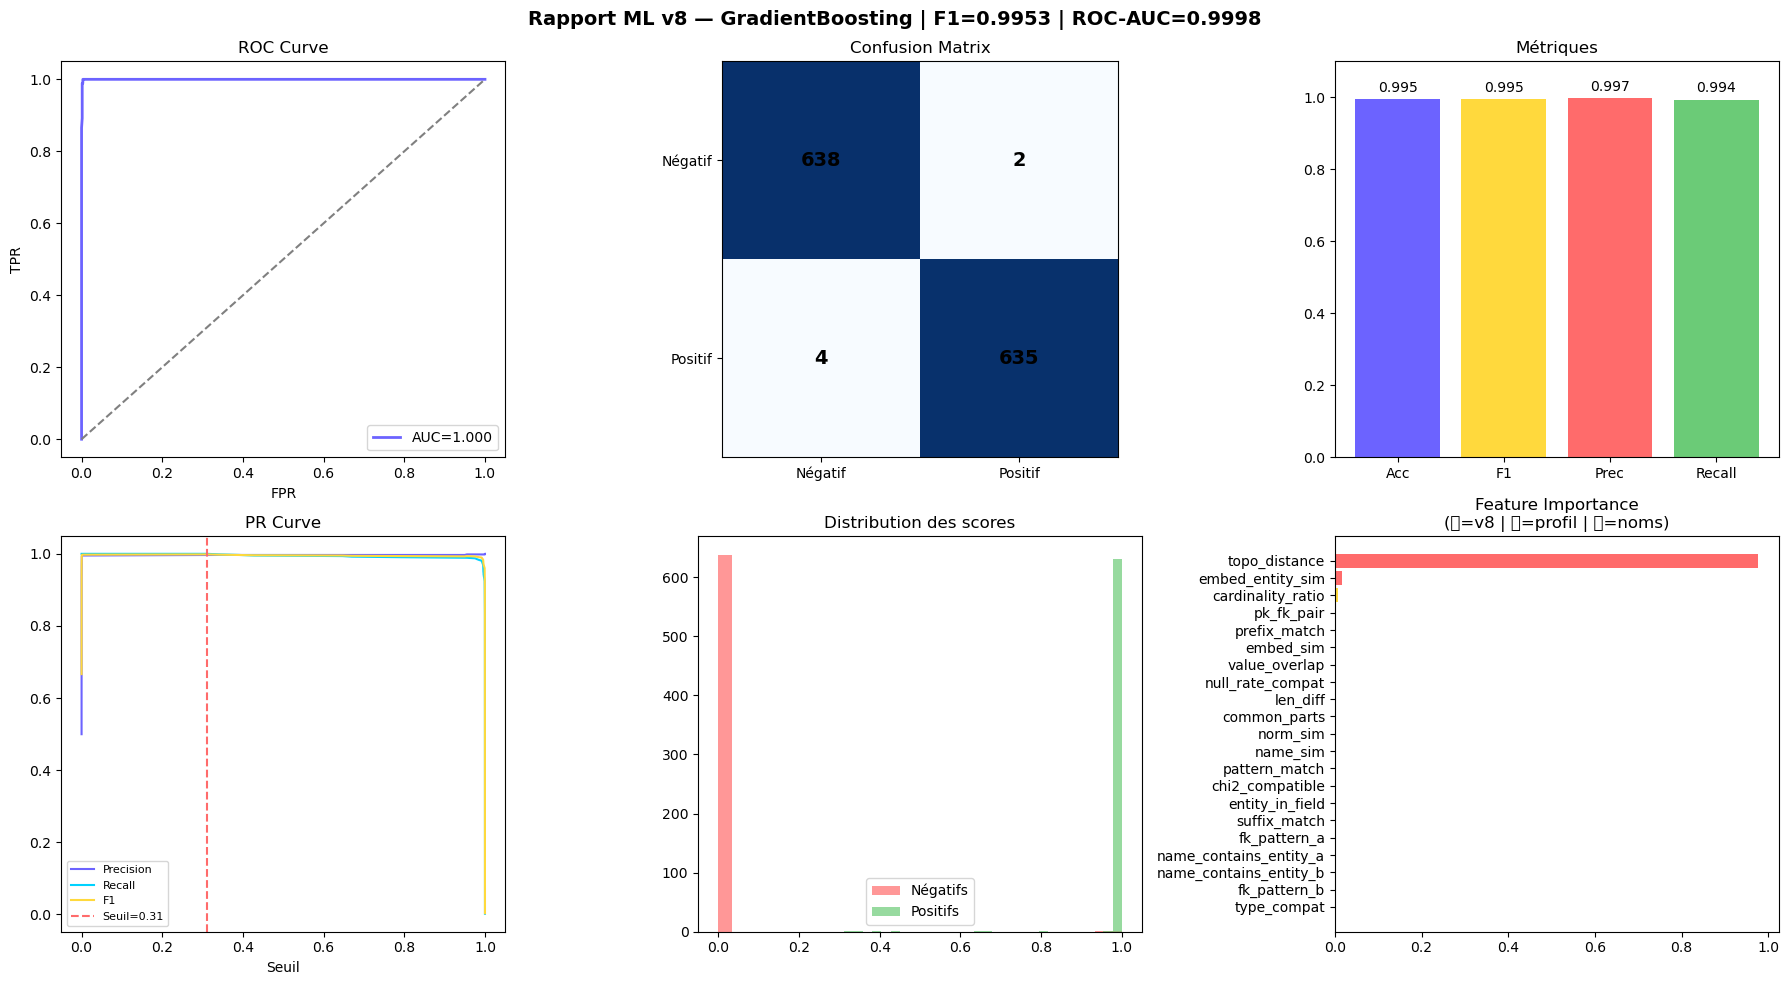

✅ Rapport GradientBoosting


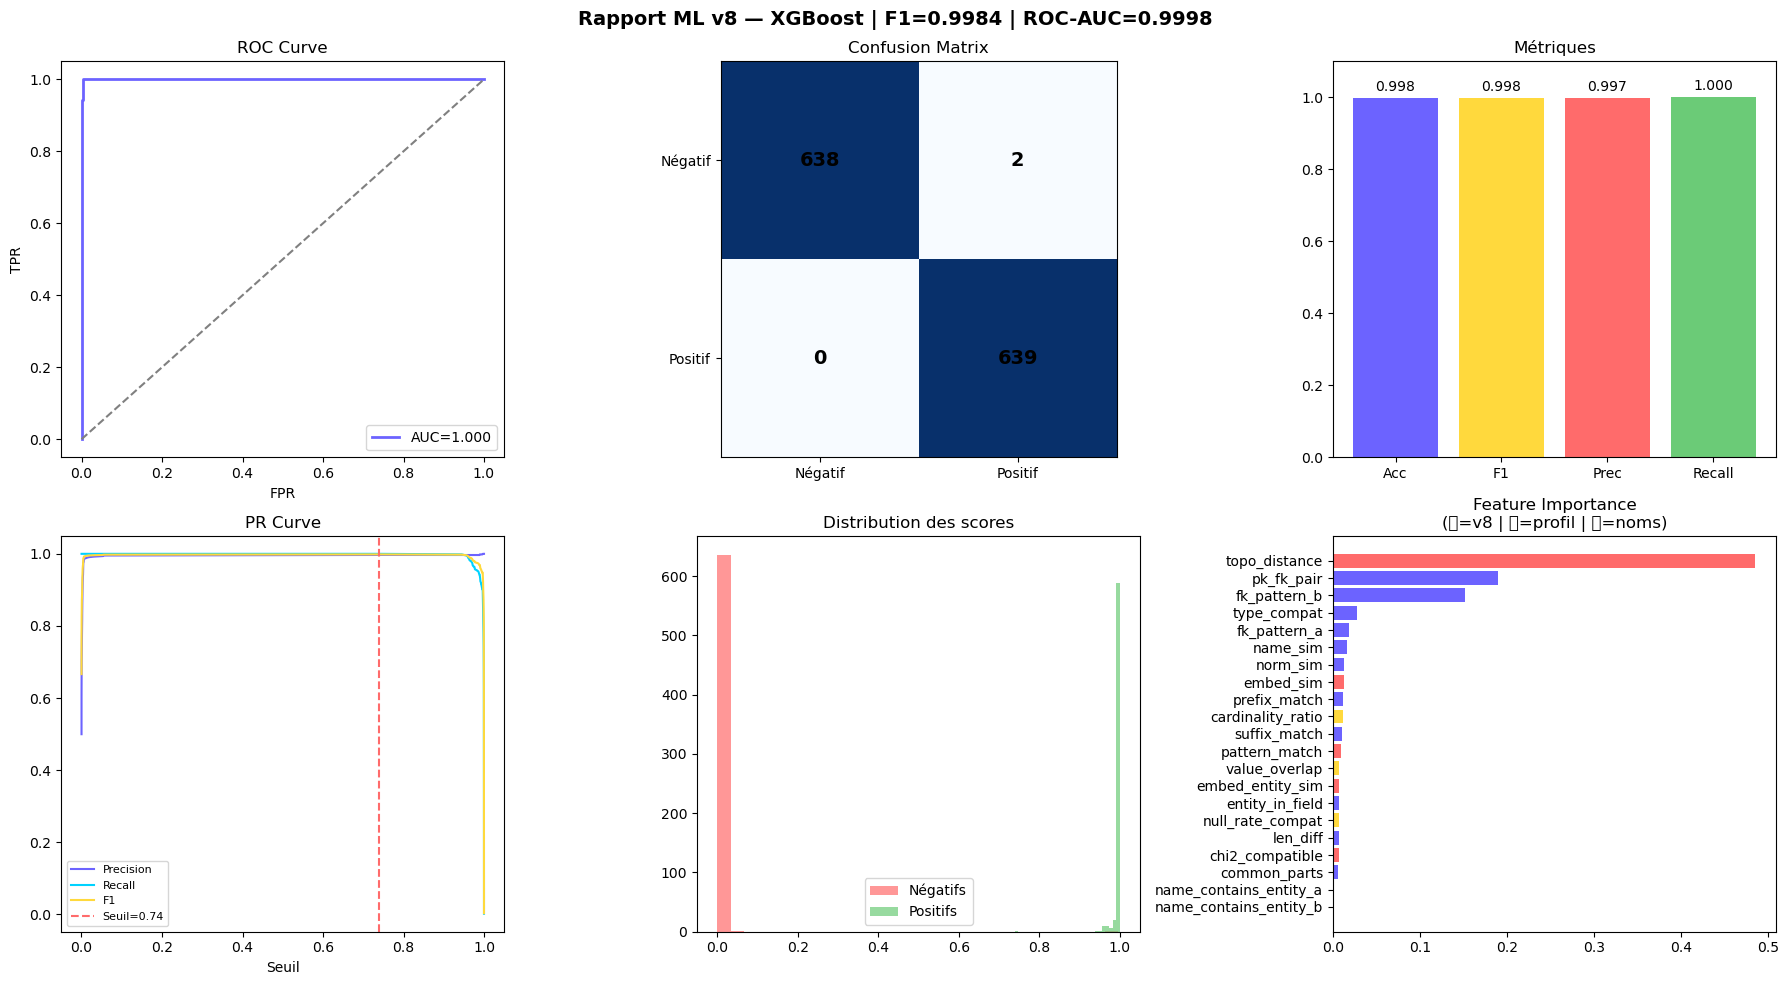

✅ Rapport XGBoost


In [18]:
for name, r in results.items():
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'Rapport ML v8 \u2014 {name} | F1={r["f1"]:.4f} | ROC-AUC={r["roc_auc"]:.4f}',
                 fontsize=14, fontweight='bold')

    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    axes[0,0].plot(fpr,tpr,color='#6c63ff',lw=2,label=f'AUC={r["roc_auc"]:.3f}')
    axes[0,0].plot([0,1],[0,1],'--',color='gray')
    axes[0,0].set_title('ROC Curve'); axes[0,0].legend()
    axes[0,0].set_xlabel('FPR'); axes[0,0].set_ylabel('TPR')

    cm = r['cm']; axes[0,1].imshow(cm, cmap='Blues')
    axes[0,1].set_title('Confusion Matrix')
    for i in range(2):
        for j in range(2):
            axes[0,1].text(j,i,cm[i,j],ha='center',va='center',fontsize=14,fontweight='bold')
    axes[0,1].set_xticks([0,1]); axes[0,1].set_yticks([0,1])
    axes[0,1].set_xticklabels(['N\u00e9gatif','Positif'])
    axes[0,1].set_yticklabels(['N\u00e9gatif','Positif'])

    m = {'Acc':r['acc'],'F1':r['f1'],'Prec':r['prec'],'Recall':r['rec']}
    bars = axes[0,2].bar(m.keys(),m.values(),color=['#6c63ff','#ffd93d','#ff6b6b','#6bcb77'])
    axes[0,2].set_ylim(0,1.1); axes[0,2].set_title('M\u00e9triques')
    for bar,v in zip(bars,m.values()):
        axes[0,2].text(bar.get_x()+bar.get_width()/2,v+0.02,f'{v:.3f}',ha='center',fontsize=10)

    prec_c,rec_c,thr_c = precision_recall_curve(y_test,r['y_proba'])
    f1_c = 2*prec_c[:-1]*rec_c[:-1]/(prec_c[:-1]+rec_c[:-1]+1e-9)
    axes[1,0].plot(thr_c,prec_c[:-1],color='#6c63ff',label='Precision')
    axes[1,0].plot(thr_c,rec_c[:-1], color='#00d2ff',label='Recall')
    axes[1,0].plot(thr_c,f1_c,        color='#ffd93d',label='F1')
    axes[1,0].axvline(thr_c[np.argmax(f1_c)],color='#ff6b6b',linestyle='--',
                      label=f'Seuil={thr_c[np.argmax(f1_c)]:.2f}')
    axes[1,0].set_title('PR Curve'); axes[1,0].legend(fontsize=8); axes[1,0].set_xlabel('Seuil')

    axes[1,1].hist(r['y_proba'][y_test==0],bins=30,alpha=0.7,color='#ff6b6b',label='N\u00e9gatifs')
    axes[1,1].hist(r['y_proba'][y_test==1],bins=30,alpha=0.7,color='#6bcb77',label='Positifs')
    axes[1,1].set_title('Distribution des scores'); axes[1,1].legend()

    if hasattr(r['model'],'feature_importances_'):
        imp = r['model'].feature_importances_; idx = np.argsort(imp)
        colors_fi = ['#ff6b6b' if ACTIVE_FEATURE_COLS[i] in V8_FEATURES
                     else '#ffd93d' if ACTIVE_FEATURE_COLS[i] in PROF_FEATURES
                     else '#6c63ff' for i in idx]
        axes[1,2].barh([ACTIVE_FEATURE_COLS[i] for i in idx],imp[idx],color=colors_fi)
        axes[1,2].set_title('Feature Importance\n(\U0001f534=v8 | \U0001f7e1=profil | \U0001f7e3=noms)')

    plt.tight_layout()
    plt.savefig(f'ml_report_v8_{name.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'\u2705 Rapport {name}')


## 11. 🔄 Cross-Validation 5-fold

In [19]:
print(f'\U0001f504 Cross-Validation 5-fold sur {BEST_MODEL_NAME}...\n')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for metric, scoring in [('Accuracy','accuracy'), ('F1','f1')]:
    scores = cross_val_score(BEST_MODEL, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    print(f'  {metric:10s} : {scores.mean():.4f} \u00b1 {scores.std():.4f}  '
          f'(min={scores.min():.4f} max={scores.max():.4f})')
print('\n\u2705 Cross-validation termin\u00e9e')


🔄 Cross-Validation 5-fold sur XGBoost...

  Accuracy   : 0.9983 ± 0.0013  (min=0.9961 max=0.9992)
  F1         : 0.9983 ± 0.0012  (min=0.9961 max=0.9992)

✅ Cross-validation terminée


## 12. 🎯 Prédiction sur Paires Inconnues v8

📊 Seuil : 0.739 | Prec=0.997 | Rec=1.000 | F1=0.998


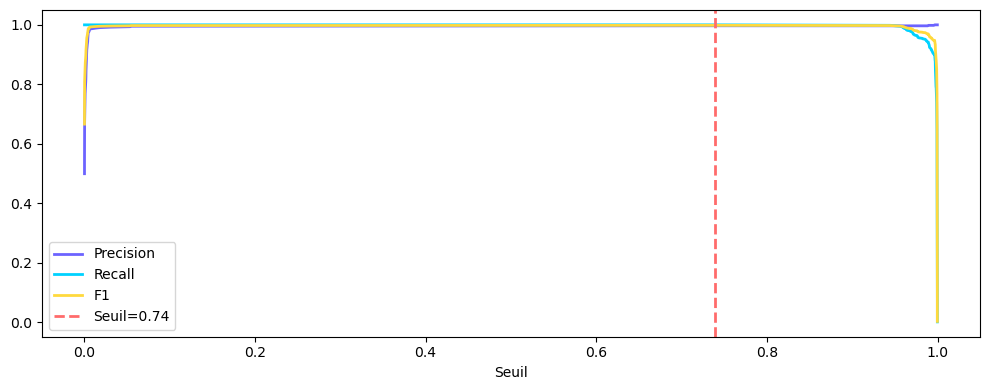

⏳ Précalcul 1347 embeddings...


Batches:   0%|          | 0/11 [00:00<?, ?it/s]

✅ 1347 embeddings précalculés

🔗 FK : 3,808 | 🔑 PK : 600 | Paires est. : 2,284,800
⚠️  Sous-échantillonnage → 50,000 paires
⏳ Calcul features sur 50,000 paires...

🎯 51 relations prédites (seuil=0.739)
   Conf. moy=0.989 | max=1.000


,source_entity,source_field,target_entity,target_field,confidence
2,AA_LTUSRTL,LTUSRTLD_ID_DTCNC,AA_AALTUSRTL_PARAMS_A,AALTUSRTL_PARAMS_ID,0.999625
4,CS_AB_FLTR_2_BNK,BNK_ID,CS_BCNTTRM_A,BCNTTRM_ID,0.999621
22,CS_INTC_LINK,CMP_ID_TO,CS_INTC_CH_2_LNK,INTC_CHRT_ID,0.999608
1,AA_ACCAU,AU2EMP_ID,AA_LT_2_ACCAU_CAU,LT_ID,0.999590
33,CS_SP,CMP_ID_CMP,CS_SP_U,UDFDEF_ID,0.999585
30,CS_RPT_BA_F,FLOWCDS_ID_HOFCD,CS_RPT_BA_F_2_ACC,CSH2ACC_ID,0.999582
27,CS_RPT_BA_F,BUDGCDS_ID_COMBD,CS_RPT_BA_F_2_CMP,CMP_ID,0.999581
36,CS_TRNTP,BUDGCDS_ID_DVBCRBDG,CS_TRNTP_SBY,TRNTP_ID,0.999570
26,CS_RPT_BA_F,BUDGCDS_ID_CIBD,CS_RPT_BA_F_2_CMP,RPT_BA_F_ID,0.999570
21,CS_INTC_CHRT,CUR_ID,CS_ACCPL,ACCPL_ID,0.999569


In [20]:
precisions_pr, recalls_pr, thresholds_pr = precision_recall_curve(
    y_test, results[BEST_MODEL_NAME]['y_proba']
)
f1_pr    = 2*(precisions_pr[:-1]*recalls_pr[:-1])/(precisions_pr[:-1]+recalls_pr[:-1]+1e-9)
best_idx = np.argmax(f1_pr)
THRESHOLD = float(thresholds_pr[best_idx])
print(f'\U0001f4ca Seuil : {THRESHOLD:.3f} | Prec={precisions_pr[best_idx]:.3f} | Rec={recalls_pr[best_idx]:.3f} | F1={f1_pr[best_idx]:.3f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds_pr, precisions_pr[:-1], color='#6c63ff', label='Precision', lw=2)
ax.plot(thresholds_pr, recalls_pr[:-1],    color='#00d2ff', label='Recall',    lw=2)
ax.plot(thresholds_pr, f1_pr,              color='#ffd93d', label='F1',        lw=2)
ax.axvline(THRESHOLD, color='#ff6b6b', linestyle='--', lw=2, label=f'Seuil={THRESHOLD:.2f}')
ax.set_xlabel('Seuil'); ax.legend(); plt.tight_layout(); plt.show()

# v8 : Précalcul embeddings en batch
if HAS_EMBED:
    all_texts = set()
    for _, r in df_fields.iterrows():
        all_texts.add(r['field_name'].replace('_',' ').lower())
        all_texts.add(r['entity_name'].replace('_',' ').lower())
    uncached = [t for t in all_texts if t not in _embed_cache]
    if uncached:
        print(f'\u23f3 Pr\u00e9calcul {len(uncached)} embeddings...')
        vecs = _EMBED_MODEL.encode(uncached, batch_size=128, show_progress_bar=True)
        for t, v in zip(uncached, vecs): _embed_cache[t] = v
        print(f'\u2705 {len(uncached)} embeddings pr\u00e9calcul\u00e9s')

fk_by_table = defaultdict(list)
for _, r in df_fields.iterrows():
    if r['is_foreign_key'] or fk_pat(r['field_name']) > 0:
        fk_by_table[r['entity_name']].append(r)

fk_cands = []
for table, cols in fk_by_table.items():
    expl = [c for c in cols if c['is_foreign_key']]
    impl = [c for c in cols if not c['is_foreign_key']]
    selected = expl[:FK_PER_TABLE]
    rem = FK_PER_TABLE - len(selected)
    if rem > 0: selected += impl[:rem]
    fk_cands += selected

pk_cands = list(df_fields[df_fields['is_primary_key']==True].iterrows())[:PK_CAP]
print(f'\n\U0001f517 FK : {len(fk_cands):,} | \U0001f511 PK : {len(pk_cands):,} | Paires est. : {len(fk_cands)*len(pk_cands):,}')

all_pairs_meta = []
for fa in fk_cands:
    for _, fb in pk_cands:
        if fa['entity_name'] == fb['entity_name']: continue
        if (fa['entity_name'],fb['entity_name']) in positive_set: continue
        all_pairs_meta.append((fa, fb))

if len(all_pairs_meta) > PAIRS_MAX:
    random.seed(42)
    all_pairs_meta = random.sample(all_pairs_meta, PAIRS_MAX)
    print(f'\u26a0\ufe0f  Sous-\u00e9chantillonnage \u2192 {PAIRS_MAX:,} paires')

print(f'\u23f3 Calcul features sur {len(all_pairs_meta):,} paires...')
unknown_pairs = []
for fa, fb in all_pairs_meta:
    feat = compute_features(
        fa['entity_name'],fa['field_name'],fa.get('data_type','varchar'),
        fa['is_primary_key'],fa['is_foreign_key'],
        fb['entity_name'],fb['field_name'],fb.get('data_type','varchar'),
        fb['is_primary_key'],fb['is_foreign_key']
    )
    feat.update({'source_entity':fa['entity_name'],'source_field':fa['field_name'],
                 'target_entity':fb['entity_name'],'target_field':fb['field_name']})
    unknown_pairs.append(feat)

df_unknown = pd.DataFrame(unknown_pairs)
for col in ACTIVE_FEATURE_COLS:
    if col not in df_unknown.columns: df_unknown[col] = 0.0

proba = BEST_MODEL.predict_proba(df_unknown[ACTIVE_FEATURE_COLS].values)[:, 1]
df_unknown['confidence'] = proba

df_preds = (
    df_unknown[df_unknown['confidence'] >= THRESHOLD]
    .sort_values('confidence', ascending=False)
    .groupby(['source_entity','source_field']).first().reset_index()
    .sort_values('confidence', ascending=False)
    .pipe(lambda df: df.head(MAX_RESULTS) if MAX_RESULTS else df)
)

print(f'\n\U0001f3af {len(df_preds):,} relations pr\u00e9dites (seuil={THRESHOLD:.3f})')
print(f'   Conf. moy={df_preds["confidence"].mean():.3f} | max={df_preds["confidence"].max():.3f}')
display(df_preds[['source_entity','source_field','target_entity','target_field','confidence']].head(25))


## 13. 📊 Visualisation des Prédictions

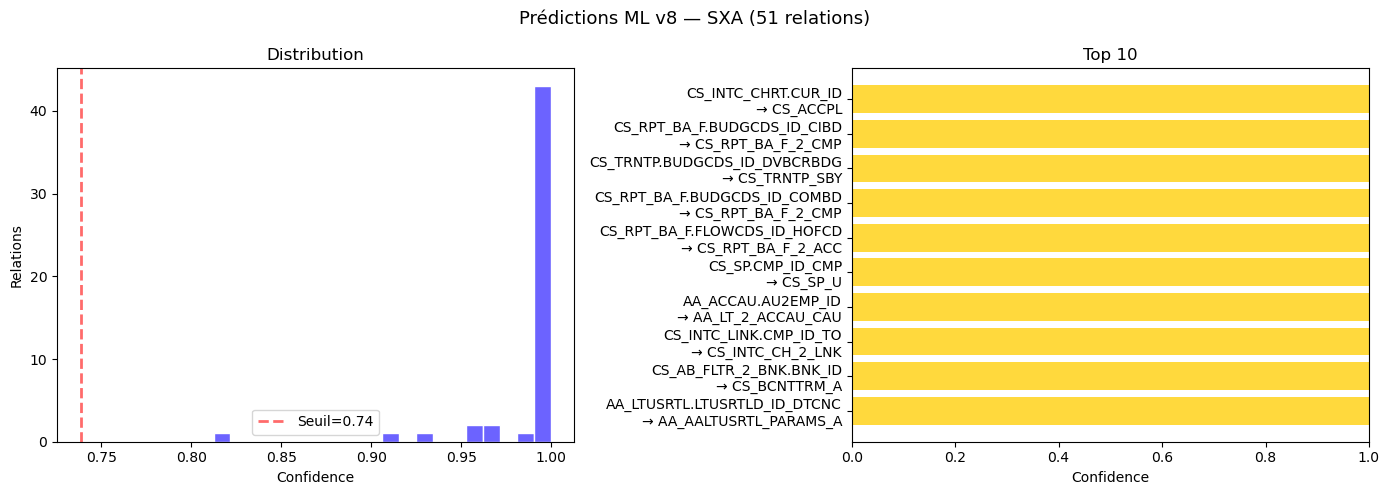

✅ ml_predictions_v8.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Pr\u00e9dictions ML v8 \u2014 {SOURCE_NAME} ({len(df_preds)} relations)', fontsize=13)
axes[0].hist(df_preds['confidence'], bins=20, color='#6c63ff', edgecolor='white')
axes[0].axvline(THRESHOLD, color='#ff6b6b', linestyle='--', lw=2, label=f'Seuil={THRESHOLD:.2f}')
axes[0].set_title('Distribution'); axes[0].legend()
axes[0].set_xlabel('Confidence'); axes[0].set_ylabel('Relations')
top10 = df_preds.head(10)
labels = [f'{r.source_entity}.{r.source_field}\n\u2192 {r.target_entity}' for _,r in top10.iterrows()]
axes[1].barh(labels, top10['confidence'], color='#ffd93d')
axes[1].set_xlim(0,1); axes[1].set_title('Top 10'); axes[1].set_xlabel('Confidence')
plt.tight_layout()
plt.savefig('ml_predictions_v8.png', dpi=150, bbox_inches='tight')
plt.show()
print('\u2705 ml_predictions_v8.png')


## 14. 💾 Sauvegarde en Base de Données

In [22]:
conn = await get_conn()

deleted = await conn.execute("""
    DELETE FROM entity_relations
    WHERE source_id=$1 AND detection_method='ml_predicted'
""", SOURCE_ID)
print(f'🗑️  Anciennes prédictions supprimées : {deleted}')

inserted = errors = 0
for _, row in df_preds.iterrows():
    try:
        await conn.execute("""
            INSERT INTO entity_relations
                (source_id, source_entity, source_field,
                 target_entity, target_field, detection_method, confidence)
            VALUES ($1,$2,$3,$4,$5,'ml_predicted',$6)
            ON CONFLICT (source_id, source_entity, source_field, target_entity)
            DO UPDATE SET
                confidence       = EXCLUDED.confidence,
                detection_method = EXCLUDED.detection_method
        """,
            SOURCE_ID,
            row['source_entity'], row['source_field'],
            row['target_entity'], row['target_field'],
            float(row['confidence'])
        )
        inserted += 1
    except Exception as e:
        errors += 1
        if errors <= 5:
            print(f'  ⚠️  {row["source_entity"]}.{row["source_field"]} → {row["target_entity"]}: {e}')

await conn.close()
print(f'\n✅ {inserted} insérées | ❌ {errors} erreurs')


🗑️  Anciennes prédictions supprimées : DELETE 2774

✅ 51 insérées | ❌ 0 erreurs


## 15. 💿 Sauvegarde du Modèle (.pkl) v8

**v8 :** pkl enrichi avec `feature_cols_v2`, `active_cols`, `use_v2`, `embed_available`, `stem_available`

In [23]:
# Correct — spécifique à la source
model_path = f'best_model_{BEST_MODEL_NAME.lower()}_{SOURCE_ID}.pkl'
with open(model_path, 'wb') as f:
    pickle.dump({
        'model':           BEST_MODEL,
        'model_name':      BEST_MODEL_NAME,
        'feature_cols':    FEATURE_COLS,
        'feature_cols_v2': FEATURE_COLS_V2,
        'active_cols':     ACTIVE_FEATURE_COLS,
        'use_v2':          USE_V2_FEATURES,
        'embed_available': HAS_EMBED,
        'stem_available':  HAS_STEM,
        'source_id':       str(SOURCE_ID),
        'threshold':       THRESHOLD,
        'trained_at':      datetime.utcnow().isoformat(),
        'metrics': {
            'f1':        results[BEST_MODEL_NAME]['f1'],
            'roc_auc':   results[BEST_MODEL_NAME]['roc_auc'],
            'precision': results[BEST_MODEL_NAME]['prec'],
            'recall':    results[BEST_MODEL_NAME]['rec'],
        },
    }, f)
print(f'\u2705 {model_path} sauvegard\u00e9 ({len(ACTIVE_FEATURE_COLS)} features)')

conn = await get_conn()
_q = "SELECT detection_method, COUNT(*) AS total, ROUND(AVG(confidence)::numeric,3) AS avg_conf FROM entity_relations WHERE source_id=$1 GROUP BY detection_method ORDER BY total DESC"
summary = await conn.fetch(_q, SOURCE_ID)
await conn.close()

print('\n\U0001f4cb R\u00e9sum\u00e9 relations en DB :')
display(pd.DataFrame([dict(r) for r in summary]))

r = results[BEST_MODEL_NAME]
print(f'\n\U0001f389 Pipeline ML v8 termin\u00e9 !')
print(f'   Mod\u00e8le    : {BEST_MODEL_NAME}')
print(f'   Features  : {len(ACTIVE_FEATURE_COLS)} ({"21 v8" if USE_V2_FEATURES else "16 v7"})')
print(f'   F1        : {r["f1"]:.4f} | ROC-AUC : {r["roc_auc"]:.4f}')
print(f'   Precision : {r["prec"]:.4f} | Recall  : {r["rec"]:.4f}')
print(f'   Seuil     : {THRESHOLD:.3f} | Ins\u00e9r\u00e9es : {inserted}')
print(f'   Stemming  : {HAS_STEM} | Embeddings : {HAS_EMBED} | Scipy : {HAS_SCIPY}')
print(f'   \u2192 OnePilot UI : http://localhost:3000')


✅ best_model_xgboost_85a0ef4b-d9af-494f-b24f-ff710c21ba43.pkl sauvegardé (21 features)

📋 Résumé relations en DB :


,detection_method,total,avg_conf
0,explicit_fk,2482,1.000
1,heuristic_name_pascal,559,0.828
2,heuristic_value_based,157,0.817
3,ml_predicted,51,0.989
4,heuristic_name_m2m,9,0.891
5,heuristic_fuzzy_match,8,0.680



🎉 Pipeline ML v8 terminé !
   Modèle    : XGBoost
   Features  : 21 (21 v8)
   F1        : 0.9984 | ROC-AUC : 0.9998
   Precision : 0.9969 | Recall  : 1.0000
   Seuil     : 0.739 | Insérées : 51
   Stemming  : True | Embeddings : True | Scipy : True
   → OnePilot UI : http://localhost:3000


## 16. ✅ Validation en masse des relations (optionnel)

In [24]:
import aiohttp

API_BASE = 'http://onepilot_api:8000'
SEUIL    = 0.70   # étape 1 : 70-100% | passer à 0.56 pour étape 2

async def bulk_validate():
    conn2 = await get_conn()
    rows = await conn2.fetch("""
        SELECT id, detection_method, confidence
        FROM entity_relations
        WHERE source_id=$1
          AND (is_confirmed IS NULL OR (is_confirmed=FALSE AND reject_reason IS NULL))
          AND confidence >= $2
        ORDER BY confidence DESC
    """, SOURCE_ID, SEUIL)
    await conn2.close()

    if not rows:
        print(f'✅ Aucune relation en attente au-dessus de {SEUIL*100:.0f}%')
        return

    print(f'📊 {len(rows)} relations à confirmer (>= {SEUIL*100:.0f}%)')
    validations = [{'id': r['id'], 'is_confirmed': True} for r in rows]
    CHUNK = 500; total = 0
    async with aiohttp.ClientSession() as session:
        for i in range(0, len(validations), CHUNK):
            chunk = validations[i:i+CHUNK]
            async with session.patch(
                f'{API_BASE}/sources/{SOURCE_ID}/relations/validate-bulk',
                json={'validated_by': 'notebook_v8', 'validations': chunk}
            ) as resp:
                result = await resp.json()
                total += result.get('validated', 0)
                print(f'  ✅ Chunk {i//CHUNK+1} : {result.get("validated",0)} confirmées')

    print(f'\n🎉 Total : {total} relations confirmées')

await bulk_validate()


📊 51 relations à confirmer (>= 70%)
  ✅ Chunk 1 : 51 confirmées

🎉 Total : 51 relations confirmées
